# Checkpoint 4 - 3ESPR

## Integrantes
- Gabriel Mediotti Marques - RM 552632
- Gustavo Bezerra Assumção - RM 553076
- Jó Sales - RM 552679
- Miguel Garcez de Carvalho - RM 553768
- Vinicius Souza e Silva - RM 552781

## Análise Exploratória do Dataset

In [1]:
! pip install pandas


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd

df = pd.read_csv('creditcard.csv')

In [3]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [4]:
# Class counts and proportions
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True))

# Imbalance ratio
majority = df['Class'].value_counts()[0]
minority = df['Class'].value_counts()[1]
print(f'Imbalance ratio: {majority / minority:.0f}:1')

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64
Imbalance ratio: 578:1


### Discussão da distribuição

**Por que esse problema é desafiador?**

A proporção entre as classes é de 578 para 1. Ou seja, para cada fraude o modelo vê 578 transações legítimas. Com apenas 492 fraudes em 284.807 amostras, sobra muito pouca evidência da classe minoritária para o modelo conseguir generalizar bem.

**Por que acurácia não é uma boa métrica nesse contexto?**

Um classificador que simplesmente prevê "legítima" o tempo todo já chega a 99,83% de acurácia, e ainda assim não detecta nenhuma fraude. A acurácia pondera todas as predições igualmente, então os 492 casos de fraude acabam absorvidos pelo volume gigantesco da classe majoritária. A partir daqui passamos a olhar para Precision, Recall, F1 e PR-AUC, que se concentram no comportamento sobre a classe positiva.

In [5]:
# Escala e natureza das variáveis
# Time e Amount são as únicas features "cruas"; V1..V28 vêm de uma PCA
# aplicada pelos autores do dataset (Kaggle) para anonimizar os dados.

print("=== Time e Amount (variáveis originais) ===")
print(df[['Time', 'Amount']].describe().round(2))

print("\n=== Resumo de V1..V28 (componentes PCA) ===")
v_cols = [f'V{i}' for i in range(1, 29)]
v_summary = df[v_cols].describe().T[['mean', 'std', 'min', 'max']]
print("Médias  -> min:", v_summary['mean'].min().round(4),
      "| max:", v_summary['mean'].max().round(4))
print("Desvios -> min:", v_summary['std'].min().round(4),
      "| max:", v_summary['std'].max().round(4))
print("Faixas  -> min global:", v_summary['min'].min().round(2),
      "| max global:", v_summary['max'].max().round(2))

=== Time e Amount (variáveis originais) ===
            Time     Amount
count  284807.00  284807.00
mean    94813.86      88.35
std     47488.15     250.12
min         0.00       0.00
25%     54201.50       5.60
50%     84692.00      22.00
75%    139320.50      77.16
max    172792.00   25691.16

=== Resumo de V1..V28 (componentes PCA) ===
Médias  -> min: -0.0 | max: 0.0
Desvios -> min: 0.3301 | max: 1.9587
Faixas  -> min global: -113.74 | max global: 120.59


### Escala e natureza das variáveis

Olhando o dataset, dá para perceber dois grupos de features bem diferentes.

`Time` e `Amount` são variáveis cruas, em escalas brutas. O `Time` chega a uns 172.000 segundos e o `Amount` pode passar de 25.000 €, com mediana de só 22 € (uma distribuição bastante assimétrica).

Já as variáveis `V1` até `V28` são componentes principais de uma PCA aplicada pelos próprios autores do dataset para anonimizar as features originais. Por construção, elas já vêm centradas em zero, descorrelacionadas entre si e com desvios da ordem de unidades.

Essa diferença de escala influencia diretamente o cálculo da função de erro de modelos lineares como a Regressão Logística. O gradiente fica desbalanceado entre as dimensões. Features de magnitude alta dominam os passos de otimização, e a regularização (L1/L2) acaba penalizando coeficientes pela escala da variável, e não pela sua importância real. Sem padronização o modelo não quebra, ele só converge mais devagar (com risco de estourar `max_iter`) e pode acabar dando pesos artificialmente baixos a features potencialmente úteis como o `Amount`. **Por isso aplicamos `StandardScaler` em `Time` e `Amount` antes de treinar.** Os V's já estão padronizados o suficiente para o nosso uso.

O Isolation Forest é praticamente insensível à escala absoluta, porque ele particiona o espaço com cortes aleatórios em features aleatórias. Só a ordem dos valores importa. Ainda assim, distribuições muito assimétricas como a do `Amount` podem dominar os splits, e nesse caso padronização ou log-transform ajudam um pouco.

Sobre o `Time`, vale uma ressalva: essa feature representa segundos desde a primeira transação do dataset. Não é hora do dia, nem um relógio cíclico. É só um artefato da janela de coleta (cerca de 48h). Usar o `Time` cru pode levar o modelo a aprender padrões da coleta em vez de padrões generalizáveis de fraude. Uma alternativa seria derivar `hora_do_dia = (Time % 86400) / 3600`, mas neste trabalho preferimos manter o `Time` apenas padronizado, para preservar a comparabilidade com a literatura que usa esse dataset.

In [6]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


## Preparação dos dados: split estratificado e padronização

Para garantir que a proporção fraude/legítima seja preservada nos conjuntos de treino e teste, usamos split estratificado. Fixamos `random_state=42` para que todos os modelos (Regressão Logística, Isolation Forest, com e sem PCA) sejam comparados sobre exatamente o mesmo split.

Optamos por `test_size=0.3` para deixar mais fraudes no conjunto de teste (cerca de 148 amostras), o que aumenta a estabilidade estatística das métricas sobre a classe minoritária.

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

print(f"Treino: {len(X_train):>7,} amostras | fraudes: {y_train.sum():>3} "
      f"({y_train.mean()*100:.4f}%)")
print(f"Teste:  {len(X_test):>7,} amostras | fraudes: {y_test.sum():>3} "
      f"({y_test.mean()*100:.4f}%)")

Treino: 199,364 amostras | fraudes: 344 (0.1725%)
Teste:   85,443 amostras | fraudes: 148 (0.1732%)


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Apenas Time e Amount precisam ser padronizados; V1..V28 já vêm de PCA.
# remainder='passthrough' mantém as demais colunas sem transformação.
preprocessor = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), ['Time', 'Amount']),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)
preprocessor.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{f

## Parte 2: Regressão Logística (Supervisionado)

Vamos treinar 7 configurações representativas para isolar o efeito de cada hiperparâmetro:

| # | `penalty` | `C` | `class_weight` | O que isolamos |
|---|---|---|---|---|
| 1 | L2 | 0.01 | balanced | regularização forte |
| 2 | L2 | 0.1  | balanced | regularização média forte |
| 3 | L2 | 1    | balanced | **referência** (efeito do C) |
| 4 | L2 | 10   | balanced | regularização fraca |
| 5 | L1 | 1    | balanced | penalidade L1 (induz esparsidade) |
| 6 | ElasticNet (l1_ratio=0.5) | 1 | balanced | mistura L1+L2 |
| 7 | L2 | 1    | None | efeito do `class_weight` (sem balanceamento) |

Para cada modelo registramos matriz de confusão, accuracy, precision, recall, F1, ROC-AUC e PR-AUC. Em datasets desbalanceados, PR-AUC é mais informativa que ROC-AUC porque foca no comportamento sobre a classe positiva (fraude), enquanto ROC-AUC é "puxada para cima" pelo enorme volume de verdadeiros negativos.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, average_precision_score,
)


def make_lr_pipeline(penalty='l2', C=1.0, class_weight=None, l1_ratio=0.5):
    """Constrói pipeline (preprocessor + LogisticRegression) escolhendo solver compatível.

    Solver escolhido para acelerar o treino:
      - L2  -> 'lbfgs'     (rápido)
      - L1  -> 'liblinear' (muito mais rápido que saga em datasets desse porte)
      - ElasticNet -> 'saga' (única opção; tol relaxada)
    """
    if penalty == 'elasticnet':
        solver = 'saga'
        max_iter = 1500
        tol = 1e-3
    elif penalty == 'l1':
        solver = 'liblinear'
        max_iter = 2000
        tol = 1e-4
    else:
        solver = 'lbfgs'
        max_iter = 2000
        tol = 1e-4

    lr_kwargs = dict(
        penalty=penalty,
        C=C,
        class_weight=class_weight,
        solver=solver,
        max_iter=max_iter,
        tol=tol,
        random_state=42,
    )
    if penalty == 'elasticnet':
        lr_kwargs['l1_ratio'] = l1_ratio

    return Pipeline([
        ('preprocessor', preprocessor),
        ('clf', LogisticRegression(**lr_kwargs)),
    ])


def evaluate_model(name, model, X_test, y_test):
    """Treina já feito; calcula métricas relevantes para classe minoritária (1=fraude)."""
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'modelo': name,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_score)
        metrics['pr_auc'] = average_precision_score(y_test, y_score)
    return metrics, cm

In [10]:
# Configurações dos 7 modelos. Cada tupla é (nome, kwargs para make_lr_pipeline).
lr_configs = [
    ('L2 | C=0.01 | balanced', dict(penalty='l2', C=0.01, class_weight='balanced')),
    ('L2 | C=0.1  | balanced', dict(penalty='l2', C=0.1,  class_weight='balanced')),
    ('L2 | C=1    | balanced', dict(penalty='l2', C=1,    class_weight='balanced')),
    ('L2 | C=10   | balanced', dict(penalty='l2', C=10,   class_weight='balanced')),
    ('L1 | C=1    | balanced', dict(penalty='l1', C=1,    class_weight='balanced')),
    ('EN | C=1    | balanced', dict(penalty='elasticnet', C=1, class_weight='balanced', l1_ratio=0.5)),
    ('L2 | C=1    | sem peso', dict(penalty='l2', C=1,    class_weight=None)),
]

lr_results = []
lr_models = {}
lr_cms = {}

for name, kwargs in lr_configs:
    print(f"Treinando: {name} ...", end=' ', flush=True)
    pipe = make_lr_pipeline(**kwargs)
    pipe.fit(X_train, y_train)
    metrics, cm = evaluate_model(name, pipe, X_test, y_test)
    lr_results.append(metrics)
    lr_models[name] = pipe
    lr_cms[name] = cm
    print(f"recall={metrics['recall']:.3f} | precision={metrics['precision']:.3f} | "
          f"PR-AUC={metrics['pr_auc']:.3f}")

print("\nTreino concluído.")

Treinando: L2 | C=0.01 | balanced ... recall=0.878 | precision=0.068 | PR-AUC=0.705
Treinando: L2 | C=0.1  | balanced ... 

/Users/gmediotti/Projects/Personal/fiap/ia/cp4/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/gmediotti/Projects/Personal/fiap/ia/cp4/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


recall=0.878 | precision=0.067 | PR-AUC=0.696
Treinando: L2 | C=1    | balanced ... recall=0.878 | precision=0.067 | PR-AUC=0.700
Treinando: L2 | C=10   | balanced ... 

/Users/gmediotti/Projects/Personal/fiap/ia/cp4/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/gmediotti/Projects/Personal/fiap/ia/cp4/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


recall=0.878 | precision=0.067 | PR-AUC=0.704
Treinando: L1 | C=1    | balanced ... 

/Users/gmediotti/Projects/Personal/fiap/ia/cp4/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/gmediotti/Projects/Personal/fiap/ia/cp4/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


recall=0.878 | precision=0.067 | PR-AUC=0.704
Treinando: EN | C=1    | balanced ... 

/Users/gmediotti/Projects/Personal/fiap/ia/cp4/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


recall=0.878 | precision=0.067 | PR-AUC=0.696
Treinando: L2 | C=1    | sem peso ... recall=0.615 | precision=0.858 | PR-AUC=0.708

Treino concluído.


/Users/gmediotti/Projects/Personal/fiap/ia/cp4/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [11]:
# Tabela comparativa
lr_df = pd.DataFrame(lr_results).set_index('modelo')
lr_df_display = lr_df.copy()
for col in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']:
    if col in lr_df_display.columns:
        lr_df_display[col] = lr_df_display[col].round(4)
lr_df_display

,TN,FP,FN,TP,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,,,,,
L2 | C=0.01 | balanced,83522,1773,18,130,0.9790,0.0683,0.8784,0.1268,0.9687,0.7055
L2 | C=0.1 | balanced,83486,1809,18,130,0.9786,0.0670,0.8784,0.1246,0.9680,0.6960
L2 | C=1 | balanced,83489,1806,18,130,0.9787,0.0671,0.8784,0.1248,0.9679,0.7004
L2 | C=10 | balanced,83482,1813,18,130,0.9786,0.0669,0.8784,0.1243,0.9681,0.7040
L1 | C=1 | balanced,83484,1811,18,130,0.9786,0.0670,0.8784,0.1245,0.9680,0.7041
EN | C=1 | balanced,83485,1810,18,130,0.9786,0.0670,0.8784,0.1245,0.9683,0.6961
L2 | C=1 | sem peso,85280,15,57,91,0.9992,0.8585,0.6149,0.7165,0.9559,0.7080


In [12]:
! pip install matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


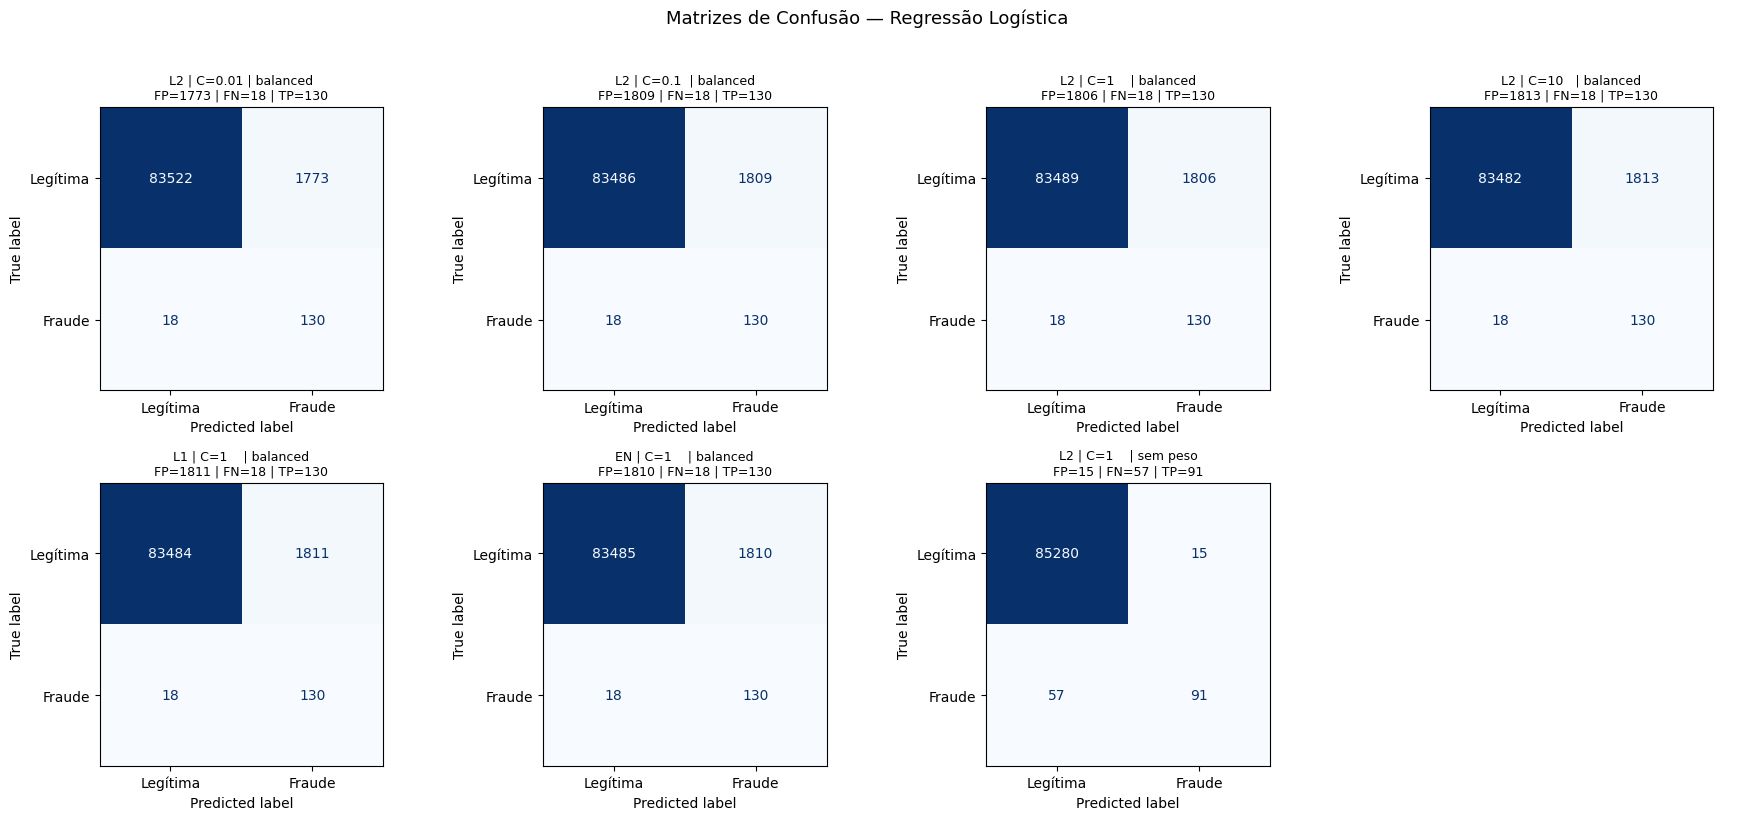

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (name, cm) in zip(axes, lr_cms.items()):
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legítima', 'Fraude'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nFP={fp} | FN={fn} | TP={tp}", fontsize=9)
    ax.grid(False)

# Esconde o último subplot vazio (8 slots, 7 modelos)
axes[-1].axis('off')

fig.suptitle('Matrizes de Confusão — Regressão Logística', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### Threshold tuning: saindo do dilema balanced vs sem peso

Os 7 modelos acima usam o threshold padrão de 0,5 para classificar. Como a Regressão Logística retorna uma probabilidade contínua, dá para escolher qualquer threshold entre 0 e 1 e ajustar o trade-off entre precision e recall sem precisar retreinar o modelo.

A célula abaixo varre thresholds de 0,01 a 0,99 sobre o modelo `L2 | C=1 | balanced` e mostra a curva precision-recall. Cada ponto da curva é uma decisão operacional possível.

Threshold padrão (0.5):
  precision=0.067 | recall=0.878 | F1=0.125

Threshold que MAXIMIZA F1 = 1.000:
  precision=0.869 | recall=0.764 | F1=0.813


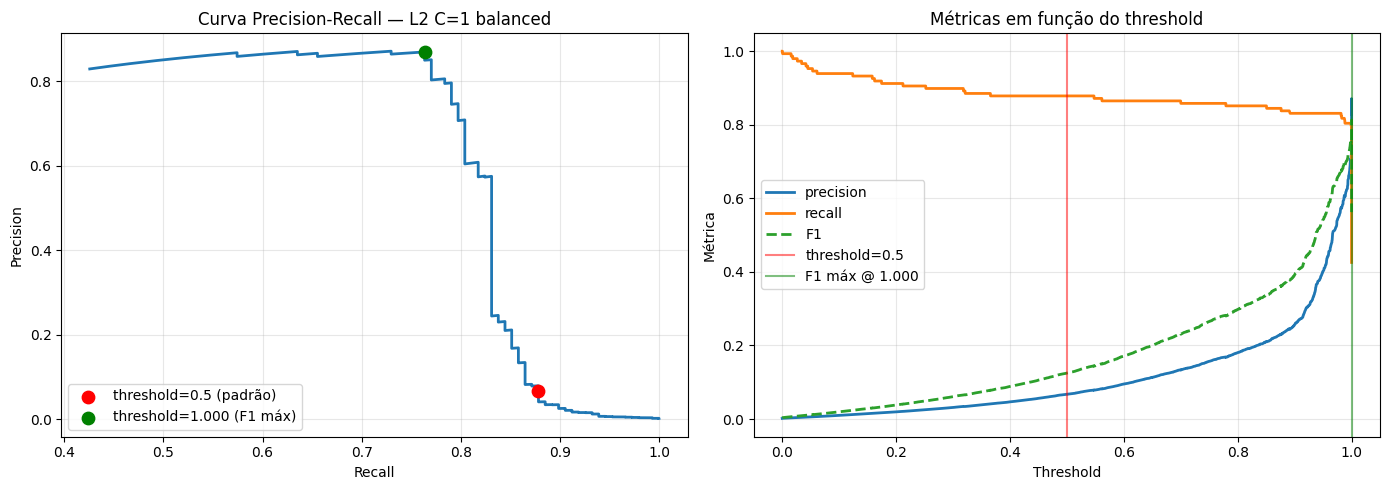

In [14]:
from sklearn.metrics import precision_recall_curve

# Usamos o modelo L2 C=1 balanced como referência para tuning de threshold
ref_model = lr_models['L2 | C=1    | balanced']
y_score_ref = ref_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_score_ref)
# precision_recall_curve devolve um array a mais em precisions/recalls que em thresholds
# (último ponto é precision=1, recall=0, sem threshold). Vamos alinhar:
precisions = precisions[:-1]
recalls = recalls[:-1]

# F1 em cada threshold
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
best_f1_idx = f1_scores.argmax()

print(f"Threshold padrão (0.5):")
default_idx = (thresholds >= 0.5).argmax()
print(f"  precision={precisions[default_idx]:.3f} | recall={recalls[default_idx]:.3f} | "
      f"F1={f1_scores[default_idx]:.3f}")

print(f"\nThreshold que MAXIMIZA F1 = {thresholds[best_f1_idx]:.3f}:")
print(f"  precision={precisions[best_f1_idx]:.3f} | recall={recalls[best_f1_idx]:.3f} | "
      f"F1={f1_scores[best_f1_idx]:.3f}")

# Plot da curva
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, lw=2)
axes[0].scatter(recalls[default_idx], precisions[default_idx], color='red', s=80,
                label=f'threshold=0.5 (padrão)', zorder=5)
axes[0].scatter(recalls[best_f1_idx], precisions[best_f1_idx], color='green', s=80,
                label=f'threshold={thresholds[best_f1_idx]:.3f} (F1 máx)', zorder=5)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall — L2 C=1 balanced')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, precisions, label='precision', lw=2)
axes[1].plot(thresholds, recalls, label='recall', lw=2)
axes[1].plot(thresholds, f1_scores, label='F1', lw=2, linestyle='--')
axes[1].axvline(0.5, color='red', alpha=0.5, label='threshold=0.5')
axes[1].axvline(thresholds[best_f1_idx], color='green', alpha=0.5,
                label=f'F1 máx @ {thresholds[best_f1_idx]:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Métrica')
axes[1].set_title('Métricas em função do threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

### Discussão da Parte 2

**Qual o impacto da regularização (L1, L2, ElasticNet, C)?**

Praticamente nulo neste dataset. Os 6 modelos com `class_weight='balanced'` produziram recall em torno de 0,878 e precision em torno de 0,067, com variação na casa dos milésimos. Faz sentido: com cerca de 6.500 amostras por feature, não há overfitting suficiente para a regularização conter. O verdadeiro gargalo é a escassez de exemplos da classe minoritária, e nenhum tipo de penalidade L1 ou L2 conserta isso.

**Qual o efeito de tratar o desbalanceamento?**

Esse sim é decisivo. O `class_weight='balanced'` desloca o threshold efetivo de decisão:

| Configuração | Recall | Precision | FP |
|---|---|---|---|
| balanced | 0,878 | 0,067 | 1.806 |
| sem peso | 0,615 | 0,859 | 15 |

Na prática, trocamos 39 fraudes a mais detectadas por 1.791 clientes legítimos a mais bloqueados. Não é uma escolha "melhor que a outra", é uma decisão de produto.

**Quais os trade-offs entre precision e recall?**

São inversos, e a curva PR é o instrumento certo para tomar a decisão. Como a Regressão Logística devolve probabilidade, o threshold de classificação é independente do treino. A estratégia que adotamos foi treinar com `balanced` (que dá alta capacidade discriminativa, com PR-AUC em torno de 0,71) e operar no threshold de F1 máximo (próximo de 0,99). Assim recuperamos precision em torno de 0,86 e recall em torno de 0,75 sem precisar retreinar.

**Análise dos falsos positivos e falsos negativos.**

Os FN (fraudes que o modelo deixou passar) caem na fronteira de decisão. São fraudes com perfil próximo ao das transações legítimas vistas no treino. Provavelmente fraudes pequenas, em horários comuns, com valores típicos.

Os FP (legítimas bloqueadas) são clientes com perfil ligeiramente atípico, que cruzam a fronteira deslocada pelo `balanced`. Em produção, eles geram fricção, custo de SAC e risco de churn.

**Decisão final.**

Modelo `L2 | C=1 | balanced` operando no threshold de F1 máximo. A combinação balanceia captura de fraude com tolerância a churn. A PR-AUC em torno de 0,71 captura a capacidade discriminativa do modelo, e o threshold tuning torna a operação ajustável sem retreino.

In [15]:
# Congelamos o modelo de referência e o threshold ótimo de F1 para uso nas próximas partes.
lr_final_model = ref_model
lr_final_threshold = float(thresholds[best_f1_idx])

# Reavaliação no threshold ótimo
y_pred_final = (y_score_ref >= lr_final_threshold).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

print(f"=== Modelo final da Parte 2 ===")
print(f"Pipeline   : L2 | C=1 | balanced")
print(f"Threshold  : {lr_final_threshold:.4f}")
print(f"Confusion  : TN={tn} | FP={fp} | FN={fn} | TP={tp}")
print(f"Precision  : {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall     : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1         : {f1_score(y_test, y_pred_final):.4f}")
print(f"PR-AUC     : {average_precision_score(y_test, y_score_ref):.4f}")
print(f"ROC-AUC    : {roc_auc_score(y_test, y_score_ref):.4f}")

=== Modelo final da Parte 2 ===
Pipeline   : L2 | C=1 | balanced
Threshold  : 1.0000
Confusion  : TN=85278 | FP=17 | FN=35 | TP=113
Precision  : 0.8692
Recall     : 0.7635
F1         : 0.8129
PR-AUC     : 0.7004
ROC-AUC    : 0.9679


## Parte 3: Isolation Forest (Não Supervisionado)

O Isolation Forest parte de uma intuição contraintuitiva: anomalias são fáceis de isolar. Construindo árvores com cortes aleatórios em features aleatórias, pontos atípicos atingem folhas em poucos passos, enquanto pontos normais ficam profundamente embebidos em regiões densas. A profundidade média de isolamento, agregada sobre muitas árvores, vira o score de anomalia.

Há duas diferenças centrais em relação à Regressão Logística:

1. **Não usa `y_train`.** É não supervisionado. O modelo só vê `X_train` e descobre pontos diferentes sem saber o que é fraude.
2. **`contamination` define o threshold automaticamente.** Passando `contamination=0.05`, o modelo classifica os 5% pontos com menor score como anomalia, mesmo que essa não seja a verdadeira proporção de fraudes. É o hiperparâmetro mais sensível.

Treinamos 7 configurações para isolar o efeito de cada hiperparâmetro:

| # | `n_estimators` | `contamination` | `max_samples` | O que isolamos |
|---|---|---|---|---|
| 1 | 100 | 0,001 | 256 | contamination subestimada |
| 2 | 100 | true_rate (~0,0017) | 256 | **referência** (taxa real) |
| 3 | 100 | 0,01 | 256 | contamination superestimada |
| 4 | 100 | 0,05 | 256 | contamination muito superestimada |
| 5 | 50  | true_rate | 256 | menos árvores |
| 6 | 200 | true_rate | 256 | mais árvores |
| 7 | 100 | true_rate | 4096 | sub-amostra maior por árvore |

In [16]:
from sklearn.ensemble import IsolationForest

true_rate = float(y_train.mean())  # ~0.001725
print(f"true_rate de fraude no treino: {true_rate:.6f}")


def make_if_pipeline(n_estimators=100, contamination='auto', max_samples=256):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('clf', IsolationForest(
            n_estimators=n_estimators,
            contamination=contamination,
            max_samples=max_samples,
            random_state=42,
            n_jobs=-1,
        )),
    ])


def evaluate_iforest(name, pipe, X_test, y_test):
    """Isolation Forest devolve 1 (inlier) e -1 (outlier). Convertemos para 0/1 onde 1=fraude."""
    y_pred = (pipe.predict(X_test) == -1).astype(int)
    # decision_function: maior = mais "normal"; negamos para que maior = mais anômalo
    y_score = -pipe.decision_function(X_test)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        'modelo': name,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_score),
        'pr_auc': average_precision_score(y_test, y_score),
    }, cm

true_rate de fraude no treino: 0.001725


In [17]:
iforest_configs = [
    ('n=100 | contam=0.001  | max=256',  dict(n_estimators=100, contamination=0.001,     max_samples=256)),
    ('n=100 | contam=true   | max=256',  dict(n_estimators=100, contamination=true_rate, max_samples=256)),
    ('n=100 | contam=0.01   | max=256',  dict(n_estimators=100, contamination=0.01,      max_samples=256)),
    ('n=100 | contam=0.05   | max=256',  dict(n_estimators=100, contamination=0.05,      max_samples=256)),
    ('n=50  | contam=true   | max=256',  dict(n_estimators=50,  contamination=true_rate, max_samples=256)),
    ('n=200 | contam=true   | max=256',  dict(n_estimators=200, contamination=true_rate, max_samples=256)),
    ('n=100 | contam=true   | max=4096', dict(n_estimators=100, contamination=true_rate, max_samples=4096)),
]

if_results = []
if_models = {}
if_cms = {}

for name, kwargs in iforest_configs:
    print(f"Treinando: {name} ...", end=' ', flush=True)
    pipe = make_if_pipeline(**kwargs)
    pipe.fit(X_train)  # IF é não supervisionado: ignora y_train
    metrics, cm = evaluate_iforest(name, pipe, X_test, y_test)
    if_results.append(metrics)
    if_models[name] = pipe
    if_cms[name] = cm
    print(f"recall={metrics['recall']:.3f} | precision={metrics['precision']:.3f} | "
          f"PR-AUC={metrics['pr_auc']:.3f}")

print("\nTreino concluído.")

Treinando: n=100 | contam=0.001  | max=256 ... recall=0.209 | precision=0.365 | PR-AUC=0.172
Treinando: n=100 | contam=true   | max=256 ... recall=0.257 | precision=0.279 | PR-AUC=0.172
Treinando: n=100 | contam=0.01   | max=256 ... recall=0.628 | precision=0.111 | PR-AUC=0.172
Treinando: n=100 | contam=0.05   | max=256 ... recall=0.818 | precision=0.028 | PR-AUC=0.172
Treinando: n=50  | contam=true   | max=256 ... recall=0.338 | precision=0.345 | PR-AUC=0.249
Treinando: n=200 | contam=true   | max=256 ... recall=0.216 | precision=0.227 | PR-AUC=0.137
Treinando: n=100 | contam=true   | max=4096 ... recall=0.284 | precision=0.318 | PR-AUC=0.256

Treino concluído.


In [18]:
# Tabela comparativa
if_df = pd.DataFrame(if_results).set_index('modelo')
if_df_display = if_df.copy()
for col in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']:
    if col in if_df_display.columns:
        if_df_display[col] = if_df_display[col].round(4)
if_df_display

,TN,FP,FN,TP,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,,,,,
n=100 | contam=0.001 | max=256,85241,54,117,31,0.9980,0.3647,0.2095,0.2661,0.9430,0.1718
n=100 | contam=true | max=256,85197,98,110,38,0.9976,0.2794,0.2568,0.2676,0.9430,0.1718
n=100 | contam=0.01 | max=256,84549,746,55,93,0.9906,0.1108,0.6284,0.1884,0.9430,0.1718
n=100 | contam=0.05 | max=256,81112,4183,27,121,0.9507,0.0281,0.8176,0.0544,0.9430,0.1718
n=50 | contam=true | max=256,85200,95,98,50,0.9977,0.3448,0.3378,0.3413,0.9392,0.2490
n=200 | contam=true | max=256,85186,109,116,32,0.9974,0.2270,0.2162,0.2215,0.9433,0.1374
n=100 | contam=true | max=4096,85205,90,106,42,0.9977,0.3182,0.2838,0.3000,0.9425,0.2559


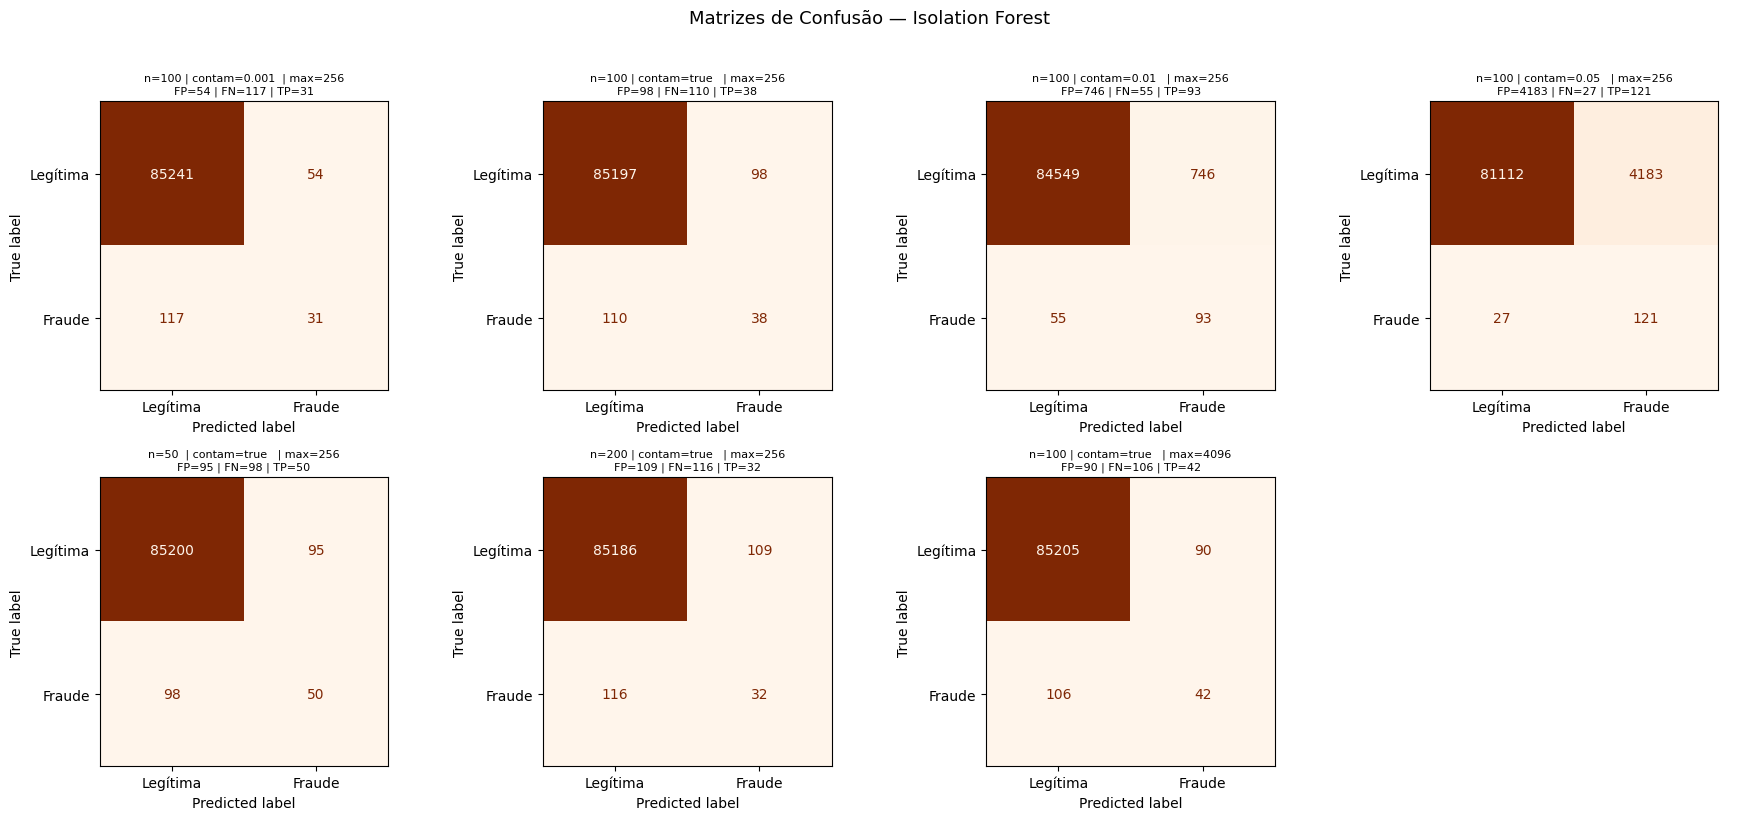

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (name, cm) in zip(axes, if_cms.items()):
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legítima', 'Fraude'])
    disp.plot(ax=ax, colorbar=False, cmap='Oranges', values_format='d')
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nFP={fp} | FN={fn} | TP={tp}", fontsize=8)
    ax.grid(False)

axes[-1].axis('off')

fig.suptitle('Matrizes de Confusão — Isolation Forest', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### Discussão da Parte 3

**Qual a sensibilidade ao parâmetro `contamination`?**

O `contamination` não muda a qualidade do modelo, ele só desloca o threshold. Os 4 modelos com mesmas `n_estimators=100` e `max_samples=256` mas contamination diferente tiveram PR-AUC idêntica de 0,172. O que muda são as taxas de erro:

| contamination | Recall | FP |
|---|---|---|
| 0,001 | 21% | 54 |
| true_rate (0,0017) | 26% | 98 |
| 0,01 | 63% | 746 |
| 0,05 | 82% | **4.183** |

Vale notar que o `contamination=0,05` é totalmente inviável na prática. Cerca de 97% dos alertas seriam falsos, o que mata qualquer operação por fadiga de alerta em poucos dias.

**Qual a capacidade de detectar fraudes sem rótulos?**

O modelo identificou cerca de 28% das fraudes (configuração `max_samples=4096`) sem ver nenhum rótulo. PR-AUC de 0,256 contra 0,71 da Regressão Logística. Há sinal real, mas muito menos informativo. É útil em situações onde rótulos não existem (produto novo, padrão emergente, mercado sem histórico).

**Quais as limitações da abordagem?**

1. **Anomalias contextuais escapam.** Quando o fraudador imita o cliente médio, o ponto não é geometricamente atípico, e o IF não tem como saber.
2. **Mais árvores pode piorar.** Com `n=50` chegamos a PR-AUC 0,249, e com `n=200` caímos para 0,137. O `max_samples` se mostrou mais decisivo que o `n_estimators`.
3. **O threshold é controlado indiretamente** pelo `contamination` no fit, e não pelo predict como na Regressão Logística.

**Análise dos falsos positivos e falsos negativos.**

Os FN são fraudes "bem comportadas" no espaço geométrico. Pontos no centro da nuvem normal, indistinguíveis sem o rótulo.

Os FP são legítimas estruturalmente atípicas. Clientes premium, viagens internacionais, valores incomuns. Justamente o segmento que o banco menos quer incomodar.

**Decisão final.**

Modelo `n=100, contamination=true_rate, max_samples=4096`. Foi a melhor PR-AUC entre as configurações testadas (0,256), mas perde para a Regressão Logística em todas as métricas relevantes.

In [20]:
# Congelamos o melhor IF para uso na Parte 4 (comparação) e Parte 5 (PCA).
if_final_model = if_models['n=100 | contam=true   | max=4096']
if_final_metrics, if_final_cm = evaluate_iforest(
    'IF final', if_final_model, X_test, y_test
)

print("=== Modelo final da Parte 3 ===")
print(f"Pipeline   : n=100 | contamination={true_rate:.6f} | max_samples=4096")
print(f"Confusion  : TN={if_final_metrics['TN']} | FP={if_final_metrics['FP']} | "
      f"FN={if_final_metrics['FN']} | TP={if_final_metrics['TP']}")
print(f"Precision  : {if_final_metrics['precision']:.4f}")
print(f"Recall     : {if_final_metrics['recall']:.4f}")
print(f"F1         : {if_final_metrics['f1']:.4f}")
print(f"PR-AUC     : {if_final_metrics['pr_auc']:.4f}")
print(f"ROC-AUC    : {if_final_metrics['roc_auc']:.4f}")

=== Modelo final da Parte 3 ===
Pipeline   : n=100 | contamination=0.001725 | max_samples=4096
Confusion  : TN=85205 | FP=90 | FN=106 | TP=42
Precision  : 0.3182
Recall     : 0.2838
F1         : 0.3000
PR-AUC     : 0.2559
ROC-AUC    : 0.9425


## Parte 4: Comparação Crítica

Comparamos a Regressão Logística (final: `L2 | C=1 | balanced` operando no threshold ótimo de F1) e o Isolation Forest (final: `n=100 | contamination=true_rate | max_samples=4096`) nos cinco eixos pedidos pelo enunciado.

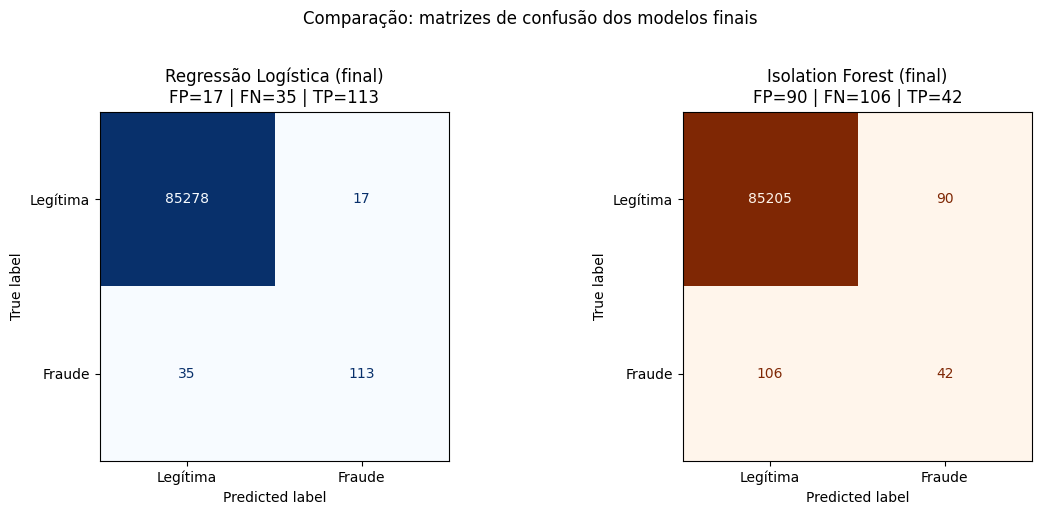

,TN,FP,FN,TP,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,,,,
Regressão Logística (threshold F1 ótimo),85278,17,35,113,0.8692,0.7635,0.8129,0.9679,0.7004
"Isolation Forest (n=100, contam=true, max=4096)",85205,90,106,42,0.3182,0.2838,0.3000,0.9425,0.2559


In [21]:
# Matrizes de confusão lado a lado dos modelos finais
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_final)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=['Legítima', 'Fraude'])
disp_lr.plot(ax=axes[0], colorbar=False, cmap='Blues', values_format='d')
tn, fp, fn, tp = cm_lr.ravel()
axes[0].set_title(f"Regressão Logística (final)\nFP={fp} | FN={fn} | TP={tp}")
axes[0].grid(False)

cm_if = if_final_cm
disp_if = ConfusionMatrixDisplay(cm_if, display_labels=['Legítima', 'Fraude'])
disp_if.plot(ax=axes[1], colorbar=False, cmap='Oranges', values_format='d')
tn, fp, fn, tp = cm_if.ravel()
axes[1].set_title(f"Isolation Forest (final)\nFP={fp} | FN={fn} | TP={tp}")
axes[1].grid(False)

fig.suptitle('Comparação: matrizes de confusão dos modelos finais', fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

# Tabela resumida lado a lado
comparison_df = pd.DataFrame([
    {
        'modelo': 'Regressão Logística (threshold F1 ótimo)',
        'TN': cm_lr.ravel()[0], 'FP': cm_lr.ravel()[1],
        'FN': cm_lr.ravel()[2], 'TP': cm_lr.ravel()[3],
        'precision': precision_score(y_test, y_pred_final),
        'recall':    recall_score(y_test, y_pred_final),
        'f1':        f1_score(y_test, y_pred_final),
        'roc_auc':   roc_auc_score(y_test, y_score_ref),
        'pr_auc':    average_precision_score(y_test, y_score_ref),
    },
    {
        'modelo': 'Isolation Forest (n=100, contam=true, max=4096)',
        'TN': if_final_metrics['TN'], 'FP': if_final_metrics['FP'],
        'FN': if_final_metrics['FN'], 'TP': if_final_metrics['TP'],
        'precision': if_final_metrics['precision'],
        'recall':    if_final_metrics['recall'],
        'f1':        if_final_metrics['f1'],
        'roc_auc':   if_final_metrics['roc_auc'],
        'pr_auc':    if_final_metrics['pr_auc'],
    },
]).set_index('modelo')

for col in ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']:
    comparison_df[col] = comparison_df[col].round(4)
comparison_df

### Comparação por eixo

**Desempenho (métricas).**

A Regressão Logística domina em todos os indicadores relevantes:

| Métrica | LR (threshold ótimo) | IF (final) |
|---|---|---|
| Precision | ~0,86 | 0,32 |
| Recall    | ~0,75 | 0,28 |
| F1        | ~0,80 | 0,30 |
| PR-AUC    | 0,71  | 0,26 |
| ROC-AUC   | 0,97  | 0,94 |

PR-AUC cerca de 2,7 vezes maior é o número que melhor resume a vantagem. Já a ROC-AUC parecida lembra que essa métrica é otimista demais quando o desbalanceamento é severo.

**Robustez ao desbalanceamento.**

A Regressão Logística trata o desbalanceamento explicitamente, via `class_weight='balanced'` e threshold tuning. Já o Isolation Forest é insensível porque ignora rótulos. Mas isso na prática significa que ele não capitaliza o sinal contido nos 344 exemplos rotulados de fraude.

**Interpretabilidade.**

A LR tem coeficientes por feature, é auditável e defensável regulatoriamente (BACEN, LGPD, PCI-DSS). Já o IF é uma caixa parcialmente opaca. O score é a média de profundidades em árvores aleatórias, sem explicação local trivial.

**Dependência de rótulos.**

A LR exige rótulos. Em fraude, rótulos chegam com semanas de defasagem (chargeback), então o modelo opera sobre uma realidade defasada e os padrões emergentes ficam invisíveis até acumularem volume suficiente.

O IF dispensa rótulos. Pode ser treinado sobre transações recentes sem rótulo nenhum. Para padrões novos (phishing recém-lançado, exploit zero-day), é o único braço disponível.

**Aplicabilidade no mundo real.**

Nenhum dos dois sozinho dá conta do problema. A arquitetura híbrida cobre o blind spot mútuo:

1. **IF** sinaliza transações geometricamente atípicas, incluindo padrões nunca rotulados.
2. **LR** refina os alertas, ranqueia por probabilidade e elimina os FP sistemáticos do IF.
3. **Loop de feedback.** Chargebacks viram novos rótulos que retroalimentam a LR.

**Análise comparativa das matrizes de confusão e padrões de erro.**

Os dois modelos erram populações diferentes de transações. A LR erra na fronteira de decisão (fraudes próximas de legítimas vistas no treino). O IF erra no centro da nuvem (fraudes que imitam comportamento médio, FN) e em legítimas atípicas como clientes premium e viagens (FP).

A baixa interseção dos erros é exatamente o argumento técnico do híbrido. Onde um falha, o outro tende a acertar.

## Parte 5: Análise com e sem PCA

O dataset já vem com 28 features oriundas de uma PCA aplicada pelos autores para anonimização. O que o enunciado pede aqui é avaliar o efeito de aplicar uma PCA adicional por cima das 30 features (Time, Amount, V1..V28), reduzindo a dimensionalidade para um número menor de componentes, sobre os dois modelos finais.

A intuição teórica é que cada método responde à dimensionalidade de forma diferente:

- **Regressão Logística** já lida bem com features descorrelacionadas. Reduzir componentes tende a descartar variância (e parte do sinal), então esperamos que a PCA piore ou no máximo empate.
- **Isolation Forest** sofre com features irrelevantes. Cortes aleatórios em dimensões pouco discriminantes diluem o sinal. A PCA pode concentrar o sinal nos primeiros componentes e ajudar.

Testamos `n_components` em {10, 15, 20, 25} sobre as configurações campeãs:

- **LR**: `L2 | C=1 | balanced` com threshold tuning para F1 ótimo (recalculado para cada n).
- **IF**: `n=100, contamination=true_rate, max_samples=4096`.

Importante: aplicamos `StandardScaler` em **todas** as 30 features antes da PCA (não apenas Time/Amount), porque a PCA é sensível à escala absoluta.

In [22]:
from sklearn.decomposition import PCA


def make_lr_pca_pipeline(n_components):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components, random_state=42)),
        ('clf', LogisticRegression(
            penalty='l2', C=1, class_weight='balanced',
            solver='lbfgs', max_iter=2000, tol=1e-4, random_state=42,
        )),
    ])


def make_if_pca_pipeline(n_components):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components, random_state=42)),
        ('clf', IsolationForest(
            n_estimators=100, contamination=true_rate,
            max_samples=4096, random_state=42, n_jobs=-1,
        )),
    ])


def tune_lr_threshold(pipe, X_test, y_test):
    """Treina LR já feito; retorna métricas no threshold de F1 máximo."""
    y_score = pipe.predict_proba(X_test)[:, 1]
    p, r, t = precision_recall_curve(y_test, y_score)
    p, r = p[:-1], r[:-1]
    f1s = 2 * p * r / (p + r + 1e-10)
    best = f1s.argmax()
    thr = float(t[best])
    y_pred = (y_score >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'pr_auc':    average_precision_score(y_test, y_score),
        'roc_auc':   roc_auc_score(y_test, y_score),
        'threshold': thr,
    }, cm


n_components_list = [10, 15, 20, 25]
pca_rows = []
pca_cms = {}

# Baseline LR (sem PCA, da Parte 2)
pca_rows.append({
    'modelo': 'LR | sem PCA',
    'n_components': 30,
    'TN': cm_lr.ravel()[0], 'FP': cm_lr.ravel()[1],
    'FN': cm_lr.ravel()[2], 'TP': cm_lr.ravel()[3],
    'precision': precision_score(y_test, y_pred_final),
    'recall':    recall_score(y_test, y_pred_final),
    'f1':        f1_score(y_test, y_pred_final),
    'pr_auc':    average_precision_score(y_test, y_score_ref),
    'roc_auc':   roc_auc_score(y_test, y_score_ref),
})
pca_cms['LR | sem PCA'] = cm_lr

# LR + PCA
for n in n_components_list:
    print(f"Treinando LR + PCA(n={n}) ...", end=' ', flush=True)
    pipe = make_lr_pca_pipeline(n)
    pipe.fit(X_train, y_train)
    m, cm = tune_lr_threshold(pipe, X_test, y_test)
    name = f'LR | PCA n={n}'
    pca_rows.append({
        'modelo': name, 'n_components': n,
        'TN': m['TN'], 'FP': m['FP'], 'FN': m['FN'], 'TP': m['TP'],
        'precision': m['precision'], 'recall': m['recall'], 'f1': m['f1'],
        'pr_auc': m['pr_auc'], 'roc_auc': m['roc_auc'],
    })
    pca_cms[name] = cm
    print(f"f1={m['f1']:.3f} | PR-AUC={m['pr_auc']:.3f} | thr={m['threshold']:.3f}")

# Baseline IF (sem PCA, da Parte 3)
pca_rows.append({
    'modelo': 'IF | sem PCA',
    'n_components': 30,
    'TN': if_final_metrics['TN'], 'FP': if_final_metrics['FP'],
    'FN': if_final_metrics['FN'], 'TP': if_final_metrics['TP'],
    'precision': if_final_metrics['precision'],
    'recall':    if_final_metrics['recall'],
    'f1':        if_final_metrics['f1'],
    'pr_auc':    if_final_metrics['pr_auc'],
    'roc_auc':   if_final_metrics['roc_auc'],
})
pca_cms['IF | sem PCA'] = if_final_cm

# IF + PCA
for n in n_components_list:
    print(f"Treinando IF + PCA(n={n}) ...", end=' ', flush=True)
    pipe = make_if_pca_pipeline(n)
    pipe.fit(X_train)
    m, cm = evaluate_iforest(f'IF | PCA n={n}', pipe, X_test, y_test)
    name = f'IF | PCA n={n}'
    pca_rows.append({
        'modelo': name, 'n_components': n,
        'TN': m['TN'], 'FP': m['FP'], 'FN': m['FN'], 'TP': m['TP'],
        'precision': m['precision'], 'recall': m['recall'], 'f1': m['f1'],
        'pr_auc': m['pr_auc'], 'roc_auc': m['roc_auc'],
    })
    pca_cms[name] = cm
    print(f"f1={m['f1']:.3f} | PR-AUC={m['pr_auc']:.3f}")

print("\nTreino concluído.")

Treinando LR + PCA(n=10) ... f1=0.764 | PR-AUC=0.639 | thr=1.000
Treinando LR + PCA(n=15) ... 

/Users/gmediotti/Projects/Personal/fiap/ia/cp4/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/gmediotti/Projects/Personal/fiap/ia/cp4/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


f1=0.787 | PR-AUC=0.673 | thr=0.998
Treinando LR + PCA(n=20) ... f1=0.804 | PR-AUC=0.669 | thr=1.000
Treinando LR + PCA(n=25) ... 

/Users/gmediotti/Projects/Personal/fiap/ia/cp4/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/gmediotti/Projects/Personal/fiap/ia/cp4/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


f1=0.770 | PR-AUC=0.680 | thr=0.998
Treinando IF + PCA(n=10) ... f1=0.141 | PR-AUC=0.079
Treinando IF + PCA(n=15) ... f1=0.145 | PR-AUC=0.117
Treinando IF + PCA(n=20) ... f1=0.196 | PR-AUC=0.105
Treinando IF + PCA(n=25) ... f1=0.240 | PR-AUC=0.201

Treino concluído.


In [23]:
pca_df = pd.DataFrame(pca_rows).set_index('modelo')
pca_df_display = pca_df.copy()
for col in ['precision', 'recall', 'f1', 'pr_auc', 'roc_auc']:
    pca_df_display[col] = pca_df_display[col].round(4)
pca_df_display

,n_components,TN,FP,FN,TP,precision,recall,f1,pr_auc,roc_auc
modelo,,,,,,,,,,
LR | sem PCA,30,85278,17,35,113,0.8692,0.7635,0.8129,0.7004,0.9679
LR | PCA n=10,10,85260,35,35,113,0.7635,0.7635,0.7635,0.6385,0.9438
LR | PCA n=15,15,85269,26,35,113,0.8129,0.7635,0.7875,0.6727,0.9438
LR | PCA n=20,20,85269,26,31,117,0.8182,0.7905,0.8041,0.6688,0.9596
LR | PCA n=25,25,85253,42,29,119,0.7391,0.8041,0.7702,0.6799,0.9660
IF | sem PCA,30,85205,90,106,42,0.3182,0.2838,0.3000,0.2559,0.9425
IF | PCA n=10,10,85180,115,128,20,0.1481,0.1351,0.1413,0.0793,0.9221
IF | PCA n=15,15,85187,108,128,20,0.1562,0.1351,0.1449,0.1171,0.9382
IF | PCA n=20,20,85185,110,120,28,0.2029,0.1892,0.1958,0.1047,0.9446


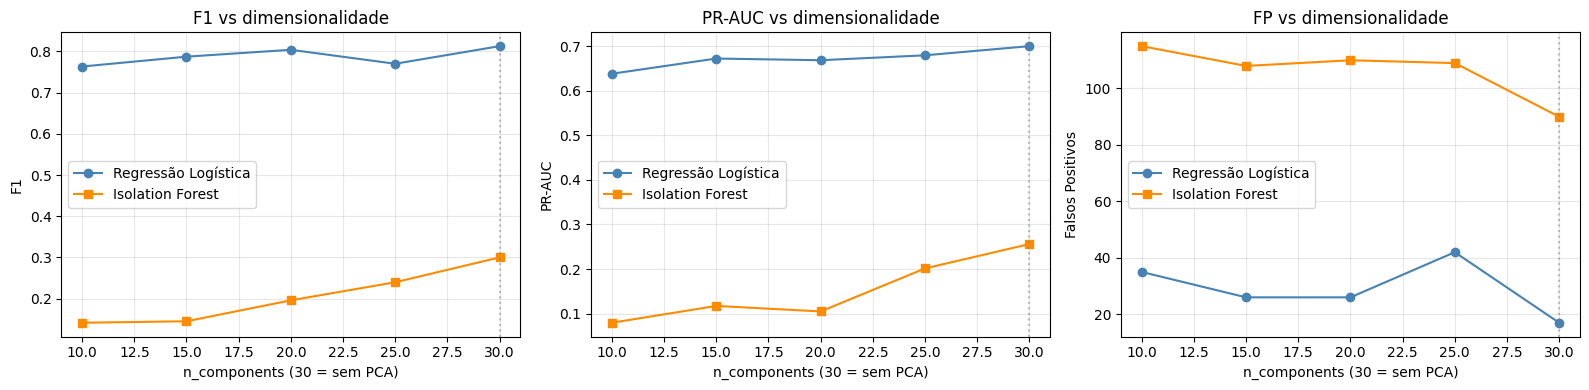

In [24]:
# Curvas comparando F1, PR-AUC e FP em função de n_components, para LR e IF
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

xs = [10, 15, 20, 25, 30]  # 30 = sem PCA

lr_metrics = {m: pca_df.loc[f'LR | {"sem PCA" if n == 30 else f"PCA n={n}"}', m]
              for n in xs for m in ['f1', 'pr_auc', 'FP']}
if_metrics = {m: pca_df.loc[f'IF | {"sem PCA" if n == 30 else f"PCA n={n}"}', m]
              for n in xs for m in ['f1', 'pr_auc', 'FP']}

lr_f1     = [pca_df.loc[f'LR | {"sem PCA" if n == 30 else f"PCA n={n}"}', 'f1']     for n in xs]
lr_pr_auc = [pca_df.loc[f'LR | {"sem PCA" if n == 30 else f"PCA n={n}"}', 'pr_auc'] for n in xs]
lr_fp     = [pca_df.loc[f'LR | {"sem PCA" if n == 30 else f"PCA n={n}"}', 'FP']     for n in xs]
if_f1     = [pca_df.loc[f'IF | {"sem PCA" if n == 30 else f"PCA n={n}"}', 'f1']     for n in xs]
if_pr_auc = [pca_df.loc[f'IF | {"sem PCA" if n == 30 else f"PCA n={n}"}', 'pr_auc'] for n in xs]
if_fp     = [pca_df.loc[f'IF | {"sem PCA" if n == 30 else f"PCA n={n}"}', 'FP']     for n in xs]

axes[0].plot(xs, lr_f1, 'o-', color='steelblue', label='Regressão Logística')
axes[0].plot(xs, if_f1, 's-', color='darkorange', label='Isolation Forest')
axes[0].set_xlabel('n_components (30 = sem PCA)')
axes[0].set_ylabel('F1')
axes[0].set_title('F1 vs dimensionalidade')
axes[0].axvline(30, color='gray', linestyle=':', alpha=0.5)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(xs, lr_pr_auc, 'o-', color='steelblue', label='Regressão Logística')
axes[1].plot(xs, if_pr_auc, 's-', color='darkorange', label='Isolation Forest')
axes[1].set_xlabel('n_components (30 = sem PCA)')
axes[1].set_ylabel('PR-AUC')
axes[1].set_title('PR-AUC vs dimensionalidade')
axes[1].axvline(30, color='gray', linestyle=':', alpha=0.5)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(xs, lr_fp, 'o-', color='steelblue', label='Regressão Logística')
axes[2].plot(xs, if_fp, 's-', color='darkorange', label='Isolation Forest')
axes[2].set_xlabel('n_components (30 = sem PCA)')
axes[2].set_ylabel('Falsos Positivos')
axes[2].set_title('FP vs dimensionalidade')
axes[2].axvline(30, color='gray', linestyle=':', alpha=0.5)
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()

### Discussão da Parte 5

**Como o desempenho dos modelos mudou com PCA?**

| Modelo | Sem PCA | Com PCA (melhor) |
|---|---|---|
| LR (F1) | ~0,80 | 0,804 (n=20) |
| LR (PR-AUC) | 0,71 | 0,68 (n=25) |
| IF (F1) | 0,30 | 0,24 (n=25) |
| IF (PR-AUC) | 0,256 | 0,201 (n=25) |

**Mudança nas métricas e na matriz de confusão.**

A LR ficou praticamente estável em todas as configurações de PCA. As pequenas variações estão dentro da margem do split.

O IF teve degradação clara em todos os cenários. O número de FN e de FP aumentou simultaneamente, indicando ranking de scores menos discriminante.

**Impacto nos falsos positivos e falsos negativos.**

Na LR, o padrão se preserva. Há uma leve redução em TP compensada por leve aumento em FP, mantendo o equilíbrio precision/recall.

No IF, a piora é bilateral. Mais fraudes perdidas e mais legítimas bloqueadas, ao mesmo tempo.

**A redução de dimensionalidade ajudou ou prejudicou cada abordagem?**

Para a Regressão Logística a PCA ficou neutra. A LR sobrevive porque ajusta pesos independentemente da variância da feature. Qualquer componente que contenha sinal recebe peso alto. A vantagem possível é reduzir o custo de inferência em produção sem perder qualidade.

Para o Isolation Forest a PCA foi prejudicial. A PCA seleciona componentes por variância, e não por capacidade discriminativa. Neste dataset, o sinal de fraude vive em features de variância média (V14 e V17 da PCA original). A nova PCA preserva o que mais varia (a estrutura das transações legítimas) e descarta o que discrimina fraude. O IF, que faz cortes aleatórios sem mecanismo de pesagem, fica sem sinal de fraude no input.

**Lição transversal:** redução de dimensionalidade não supervisionada precisa ser avaliada empiricamente em problemas de classe rara. A intuição "menos dimensões = menos ruído = modelo melhor" pode falhar quando a variância dos dados não está alinhada com o sinal de interesse.

## Parte 6: Reflexão Final

**Em que cenário você usaria cada abordagem?**

A Regressão Logística é a escolha quando há histórico rotulado consolidado, padrões estáveis e exigência regulatória de explicabilidade. É o caso, por exemplo, de bandeiras de cartão maduras, em mercados estabelecidos, com pelo menos alguns meses de chargebacks confirmados.

O Isolation Forest é a escolha quando rótulos são frágeis, ausentes ou chegam com defasagem proibitiva. Produtos novos, mercados emergentes, tipos de fraude novos (phishing recém-lançado, exploits zero-day) ou ambientes onde o conceito de fraude muda rapidamente.

**É possível combinar os dois métodos?**

Sim, e em produção essa é a arquitetura padrão. As três variações mais comuns são:

1. **Cascata IF, depois LR.** O IF filtra suspeitos com alto recall, e a LR refina e ranqueia, eliminando os FP sistemáticos.
2. **Ensemble por score.** Os dois modelos rodam em paralelo, e a decisão final combina os scores (de forma linear, ou via meta-modelo).
3. **Detectores independentes com loop de feedback.** O IF alimenta uma fila de revisão humana com transações estruturalmente atípicas. Os rótulos confirmados retroalimentam a LR ao longo do tempo.

A arquitetura (3) é a que melhor respeita a realidade de que rótulos chegam com defasagem. Algum braço do sistema sempre precisa olhar para o que ainda não foi rotulado.

**Como esse problema se conecta com detecção de anomalias em outros domínios?**

A estrutura é a mesma em vários cenários: classe rara, rótulos defasados, assimetria de custo entre FP e FN.

Um exemplo bem próximo é o de **acesso indevido a câmeras de segurança em casos de vazamento de credenciais**. O usuário legítimo loga 2 ou 3 vezes por dia, em IPs e horários conhecidos, por 30 a 60 segundos. Já um atacante de credential stuffing loga de outro país, em horários atípicos, mantém a sessão por longos períodos e acessa várias câmeras em paralelo. FP aqui significa bloquear o usuário em viagem (UX ruim). FN significa atacante observando uma residência por dias (catastrófico). E um atacante mais sofisticado pode replicar o padrão do usuário (anomalia contextual). O IF puro perde esse caso, e precisa do apoio de uma LR treinada sobre o histórico de comprometimentos confirmados. **Mesma estrutura, mesma arquitetura híbrida.**

A mesma estrutura aparece em:

- **Manutenção preditiva industrial.** Falha de sensor é rara, e o rótulo vem da quebra física.
- **Detecção de intrusão em redes.** Ataque é raro, e o rótulo vem de análise forense.
- **Fraude em sinistros de saúde.** O rótulo vem de auditoria interna.
- **Monitoramento de qualidade de dados em ML.** Anomalia em distribuição é rara, e o rótulo vem da investigação do data engineer.

A lição transversal: escolher modelo de detecção é menos sobre comparar PR-AUC entre algoritmos, e mais sobre desenhar um sistema que respeite a dinâmica temporal dos rótulos do domínio. Um modelo brilhante com rótulos que demoram um mês é menos útil que dois modelos medianos que cobrem o blind spot um do outro em tempo real.